# Differentially Private Random Forest - Lung Cancer Dataset

Trains a DP Random Forest (diffprivlib) on the Lung Cancer dataset (50k samples, 23 features, 3-class).

ε ∈ {0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0}, 30 runs each.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from diffprivlib.models import RandomForestClassifier as DPRandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score,
)
import pickle, json, os
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
bounds = data['bounds']
n_classes = data.get('n_classes', 3)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {n_classes}")

Training set: (40000, 23)
Test set: (10000, 23)
Classes: 3


## 3. Load Baseline Results

In [3]:
try:
    baseline_df = pd.read_csv('output/baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: Run STD_RF.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline Accuracy: 1.0000
Baseline F1-Score: 1.0000


## 4. Extract Bounds

In [4]:
lower_bound = bounds[0]
upper_bound = bounds[1]
print(f"Bounds shape: {lower_bound.shape}")

Bounds shape: (23,)


## 5. Quick Demo at ε=1.0 (30 Runs)

In [5]:
epsilon = 1.0
N_RUNS = 30
detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []

print(f"Training DP Random Forest {N_RUNS} times with epsilon={epsilon}...")
print('=' * 60)

detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed = run * 10 + 42
    dp_rf = DPRandomForestClassifier(
        n_estimators=20, epsilon=epsilon, random_state=seed,
        n_jobs=-1, max_depth=4, bounds=bounds
    )
    _t0 = time.perf_counter()
    dp_rf.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0
    y_pred = dp_rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    detail_extra.add(y_test, y_pred, model=dp_rf, X=X_test, train_time=train_time)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    detail_accuracies.append(acc)
    detail_f1s.append(f1)
    detail_precisions.append(prec)
    detail_recalls.append(rec)
    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

print('=' * 60)
print(f"\nMean Accuracy: {np.mean(detail_accuracies):.4f} +/- {np.std(detail_accuracies):.4f}")
print(f"Mean F1-Score: {np.mean(detail_f1s):.4f} +/- {np.std(detail_f1s):.4f}")

print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP Random Forest 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.8799 | F1: 0.8738 | Prec: 0.8975 | Rec: 0.8799


  Run  2/30 | Acc: 0.9469 | F1: 0.9463 | Prec: 0.9501 | Rec: 0.9469


  Run  3/30 | Acc: 0.9358 | F1: 0.9350 | Prec: 0.9388 | Rec: 0.9358
  Run  4/30 | Acc: 0.9072 | F1: 0.9043 | Prec: 0.9180 | Rec: 0.9072


  Run  5/30 | Acc: 0.9276 | F1: 0.9261 | Prec: 0.9338 | Rec: 0.9276


  Run  6/30 | Acc: 0.8900 | F1: 0.8852 | Prec: 0.9048 | Rec: 0.8900
  Run  7/30 | Acc: 0.9025 | F1: 0.9008 | Prec: 0.9144 | Rec: 0.9025


...

  Run 24/30 | Acc: 0.9129 | F1: 0.9097 | Prec: 0.9186 | Rec: 0.9129
  Run 25/30 | Acc: 0.8870 | F1: 0.8833 | Prec: 0.9026 | Rec: 0.8870


  Run 26/30 | Acc: 0.8373 | F1: 0.8255 | Prec: 0.8744 | Rec: 0.8373


  Run 27/30 | Acc: 0.8852 | F1: 0.8822 | Prec: 0.9102 | Rec: 0.8852
  Run 28/30 | Acc: 0.9369 | F1: 0.9366 | Prec: 0.9411 | Rec: 0.9369


  Run 29/30 | Acc: 0.8188 | F1: 0.8032 | Prec: 0.8659 | Rec: 0.8188


  Run 30/30 | Acc: 0.8485 | F1: 0.8387 | Prec: 0.8803 | Rec: 0.8485

Mean Accuracy: 0.8866 +/- 0.0405
Mean F1-Score: 0.8809 +/- 0.0456
Added metrics over the detail runs:
  Balanced Acc:   0.8840 ± 0.0411
  AUROC:          0.9864 ± 0.0064
  Train Time (s): 0.0502 ± 0.0064


## 6. Full Sweep Across All Epsilon Values

In [6]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
N_RUNS = 30

results = {
    'epsilon': [], 'accuracy_mean': [], 'accuracy_std': [],
    'f1_score_mean': [], 'f1_score_std': [],
    'precision_mean': [], 'precision_std': [],
    'recall_mean': [], 'recall_std': [],
}

all_results = {
    'model_type': 'Differentially Private Random Forest',
    'dataset': 'Lung Cancer',
    'n_samples': X_train.shape[0] + X_test.shape[0],
    'n_features': X_train.shape[1],
    'n_classes': n_classes,
    'n_runs_per_epsilon': N_RUNS,
    'epsilon_results': {}
}

print(f"Training DP RF with {N_RUNS} runs per epsilon...")
print('=' * 80)

for eps in epsilon_values:
    run_accs, run_f1s, run_precs, run_recs, run_cms = [], [], [], [], []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42
        dp_rf = DPRandomForestClassifier(
            n_estimators=20, epsilon=eps, random_state=seed,
            n_jobs=-1, max_depth=4, bounds=bounds
        )
        _t0 = time.perf_counter()
        dp_rf.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        y_pred = dp_rf.predict(X_test)
        run_accs.append(accuracy_score(y_test, y_pred))
        extra.add(y_test, y_pred, model=dp_rf, X=X_test, train_time=train_time)
        run_f1s.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
        run_precs.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        run_recs.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
        run_cms.append(confusion_matrix(y_test, y_pred).tolist())
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_rf, f'output/model/dp_rf_model_eps_{eps}.pkl')

    acc_mean, acc_std = np.mean(run_accs), np.std(run_accs)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precs), np.std(run_precs)
    rec_mean, rec_std = np.mean(run_recs), np.std(run_recs)

    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)

    all_results['epsilon_results'][str(eps)] = {
        'epsilon': float(eps), 'n_runs': N_RUNS,
        'accuracy_mean': acc_mean, 'accuracy_std': acc_std,
        'f1_mean': f1_mean, 'f1_std': f1_std,
        'precision_mean': prec_mean, 'precision_std': prec_std,
        'recall_mean': rec_mean, 'recall_std': rec_std,
        'per_run_accuracies': run_accs, 'per_run_f1s': run_f1s,
        'per_run_confusion_matrices': run_cms,
    }
    all_results['epsilon_results'][str(eps)].update(extra.summary())
    all_results['epsilon_results'][str(eps)].update(extra.per_run())

    print(f"eps={eps:5.2f} | Acc: {acc_mean:.4f}+/-{acc_std:.4f} | F1: {f1_mean:.4f}+/-{f1_std:.4f}")

print('=' * 80)
print('Training complete!')

Training DP RF with 30 runs per epsilon...


Model successfully exported to output/model/dp_rf_model_eps_0.1.pkl


eps= 0.10 | Acc: 0.8816+/-0.0444 | F1: 0.8752+/-0.0503
Model successfully exported to output/model/dp_rf_model_eps_0.2.pkl


eps= 0.20 | Acc: 0.8871+/-0.0432 | F1: 0.8813+/-0.0487
Model successfully exported to output/model/dp_rf_model_eps_0.4.pkl


eps= 0.40 | Acc: 0.8890+/-0.0429 | F1: 0.8834+/-0.0482
Model successfully exported to output/model/dp_rf_model_eps_0.6.pkl


...

eps= 2.00 | Acc: 0.8862+/-0.0416 | F1: 0.8804+/-0.0466
Model successfully exported to output/model/dp_rf_model_eps_4.0.pkl


eps= 4.00 | Acc: 0.8866+/-0.0411 | F1: 0.8809+/-0.0459
Model successfully exported to output/model/dp_rf_model_eps_6.0.pkl


eps= 6.00 | Acc: 0.8869+/-0.0407 | F1: 0.8813+/-0.0455
Model successfully exported to output/model/dp_rf_model_eps_8.0.pkl


eps= 8.00 | Acc: 0.8869+/-0.0407 | F1: 0.8813+/-0.0455
Model successfully exported to output/model/dp_rf_model_eps_10.0.pkl


eps=10.00 | Acc: 0.8869+/-0.0407 | F1: 0.8813+/-0.0455
Training complete!


## 7. Results Summary

In [7]:
results_df = pd.DataFrame(results)
if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = 1 - results_df['accuracy_mean'] / baseline_accuracy
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100
print(results_df.to_string(index=False))

 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.881553      0.044367       0.875157      0.050250        0.898906       0.032081     0.881553    0.044367                0.878793               0.045028      0.985050     0.006796         0.047459        0.006208            0.118447          11.844667
     0.2       0.887107      0.043171       0.881270      0.048693        0.904268       0.031110     0.887107    0.043171                0.884414               0.043849      0.986147     0.007602         0.050692        0.010049            0.112893          11.289333
     0.4       0.889017      0.042917       0.883400      0.048164        0.905787       0.031147     0.889017    0.042917                0.886459               0.043599      0.986363     0.007

## 8. Save Results

In [8]:
os.makedirs('output', exist_ok=True)
with open('./output/dp_rf_report.json', 'w') as f:
    json.dump(all_results, f, indent=4)
results_df.to_csv('./output/dp_results.csv', index=False)
print('Results saved to output/')

Results saved to output/


## 9. Visualization

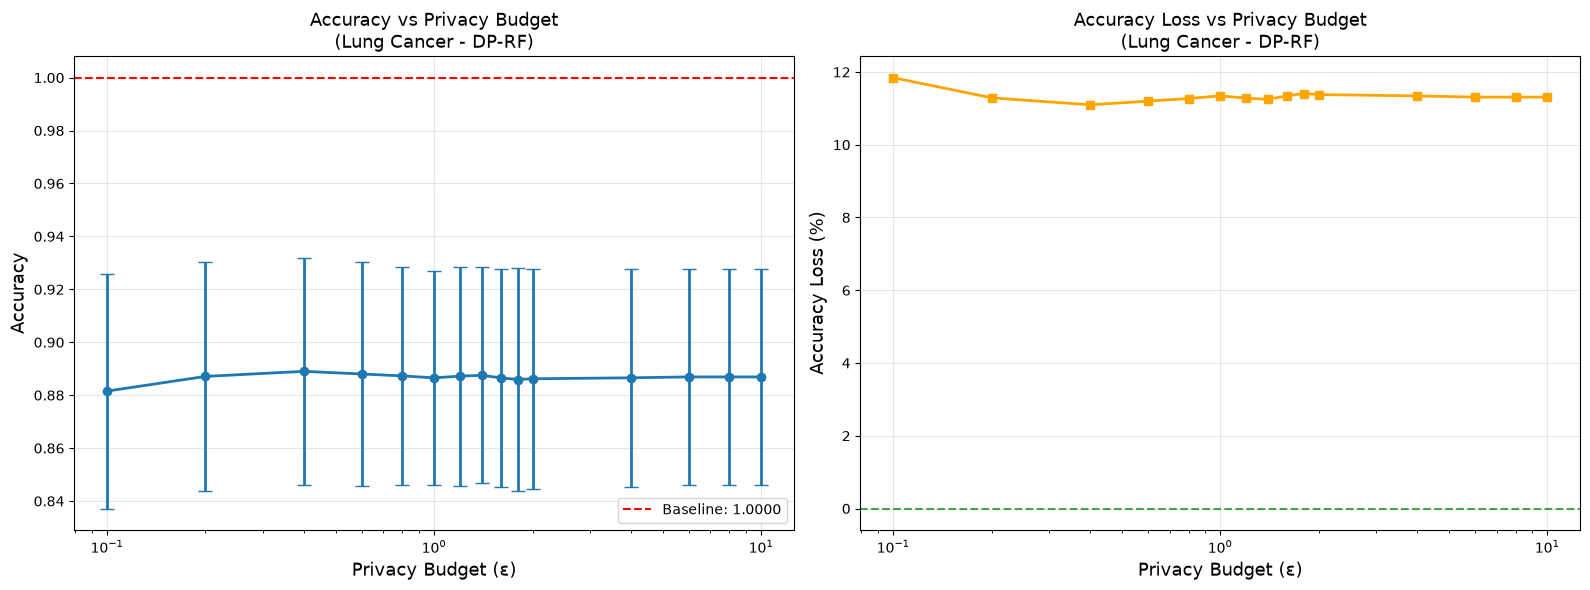

Plot saved to ./output/dp_rf_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].errorbar(results_df['epsilon'], results_df['accuracy_mean'],
                 yerr=results_df['accuracy_std'], marker='o', capsize=5, linewidth=2)
if baseline_accuracy is not None:
    axes[0].axhline(y=baseline_accuracy, color='red', linestyle='--',
                    label=f'Baseline: {baseline_accuracy:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Privacy Budget (ε)', fontsize=13)
axes[0].set_ylabel('Accuracy', fontsize=13)
axes[0].set_title('Accuracy vs Privacy Budget\n(Lung Cancer - DP-RF)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
if 'accuracy_loss_pct' in results_df.columns:
    axes[1].plot(results_df['epsilon'], results_df['accuracy_loss_pct'], marker='s', linewidth=2, color='orange')
    axes[1].axhline(y=0, color='green', linestyle='--', alpha=0.7)
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Privacy Budget (ε)', fontsize=13)
    axes[1].set_ylabel('Accuracy Loss (%)', fontsize=13)
    axes[1].set_title('Accuracy Loss vs Privacy Budget\n(Lung Cancer - DP-RF)', fontsize=13)
    axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./output/dp_rf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to ./output/dp_rf_comparison.png')